<a href="https://colab.research.google.com/github/AyatiSinha/llm-watermark-attack-detection/blob/main/notebooks/02_results_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
with open("attack_detection_log.json", "r") as f:
    data = json.load(f)

print(data.keys())

dict_keys(['statistics', 'training_metrics', 'configuration'])


In [5]:
stats = data["statistics"]

for k, v in stats.items():
    print(k, ":", v)

total_attacks_detected : 1296
attacks_by_type : {'sign_flip': 843, 'noise': 425, 'quant': 28}
correct_by_type : {'sign_flip': 265, 'noise': 183, 'quant': 28}
accuracy_by_type : {'sign_flip': 0.3143534994068802, 'noise': 0.43058823529411766, 'quant': 1.0}
attacks_prevented : 1296
avg_detection_time_ms : 12.95577762303529
attack_events : [{'step': 0, 'timestamp': '2026-08-11T14:28:42.192920', 'detected_type': 'sign_flip', 'actual_type': 'noise', 'confidence': 0.9500000000000001, 'all_scores': {'pruning': 0.0, 'noise': 0.4, 'quant': 0.1, 'sign_flip': 0.8}, 'signatures': {'bit_acc_before': 0.53125, 'bit_acc_after': 0.53125, 'bit_acc_drop': 0.0, 'norm_before': 198.58291625976562, 'norm_after': 199.15945434570312, 'norm_change_ratio': 0.002903261251105306, 'mean_before': -0.0015885832253843546, 'mean_after': -0.001581034273840487, 'std_before': 0.12927602231502533, 'std_after': 0.1296514868736267, 'std_change_ratio': 0.0029043632595903888, 'sparsity_before': 6.781684078305261e-06, 'sparsity_

In [6]:
metrics = data["training_metrics"]

for k, v in metrics.items():
    if isinstance(v, list):
        print(k, ":", len(v), "values")
    else:
        print(k, ":", v)

epoch_losses_lm : 100 values
epoch_losses_wm : 100 values
bit_accuracies : 100 values
detections_per_epoch : 100 values
preventions_per_epoch : 100 values
attack_distribution_per_epoch : 100 values


In [7]:
attack_types = stats["attacks_by_type"]
correct = stats["correct_by_type"]

rows = []

for attack, total in attack_types.items():
    right = correct.get(attack, 0)

    acc = right / total if total else 0

    rows.append({
        "Attack": attack,
        "Total": total,
        "Correct": right,
        "Accuracy": acc
    })

df = pd.DataFrame(rows)

df["Accuracy (%)"] = df["Accuracy"] * 100

df

,Attack,Total,Correct,Accuracy,Accuracy (%)
0,sign_flip,843,265,0.314353,31.435350
1,noise,425,183,0.430588,43.058824
2,quant,28,28,1.000000,100.000000


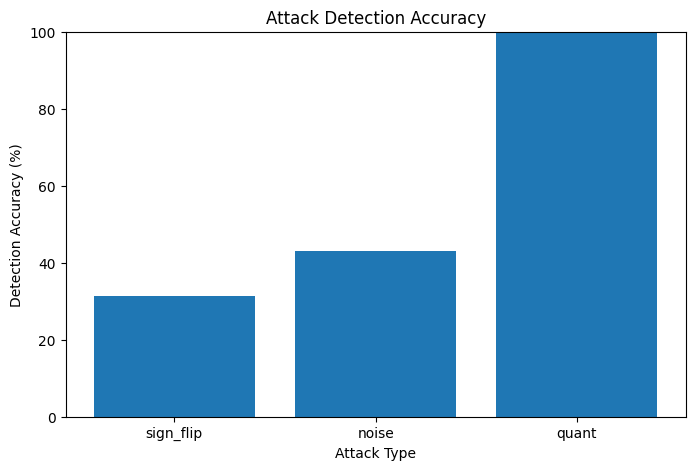

In [8]:
plt.figure(figsize=(8, 5))

plt.bar(df["Attack"], df["Accuracy (%)"])

plt.xlabel("Attack Type")
plt.ylabel("Detection Accuracy (%)")
plt.title("Attack Detection Accuracy")
plt.ylim(0, 100)

plt.show()

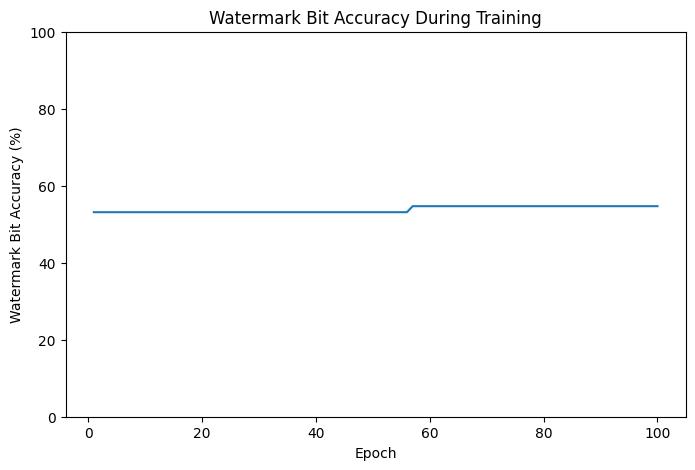

In [9]:
bit_acc = np.array(metrics["bit_accuracies"]) * 100

plt.figure(figsize=(8, 5))

plt.plot(range(1, len(bit_acc) + 1), bit_acc)

plt.xlabel("Epoch")
plt.ylabel("Watermark Bit Accuracy (%)")
plt.title("Watermark Bit Accuracy During Training")
plt.ylim(0, 100)

plt.show()

In [10]:
print(metrics.keys())

dict_keys(['epoch_losses_lm', 'epoch_losses_wm', 'bit_accuracies', 'detections_per_epoch', 'preventions_per_epoch', 'attack_distribution_per_epoch'])


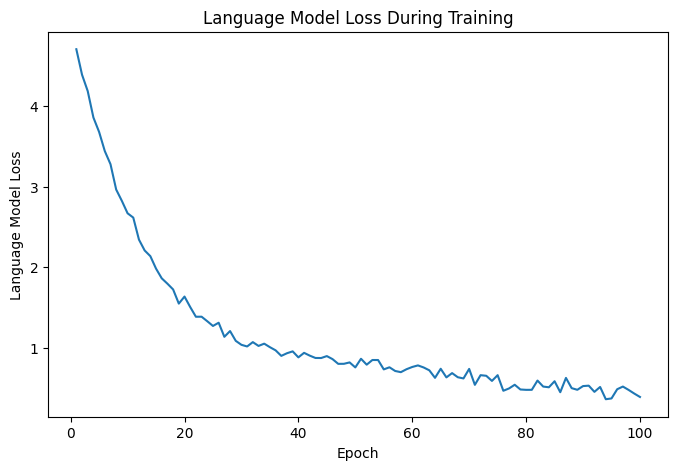

In [11]:
lm_loss = metrics["epoch_losses_lm"]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(lm_loss) + 1), lm_loss)

plt.xlabel("Epoch")
plt.ylabel("Language Model Loss")
plt.title("Language Model Loss During Training")

plt.show()

In [12]:
if "avg_detection_time_ms" in stats:
    print(
        f"Average detection time: "
        f"{stats['avg_detection_time_ms']:.2f} ms"
    )

Average detection time: 12.96 ms


In [13]:
total = df["Total"].sum()
correct = df["Correct"].sum()
overall_acc = correct / total * 100

summary = pd.DataFrame({
    "Metric": [
        "Total attack events",
        "Correct classifications",
        "Overall detection accuracy (%)",
        "Average detection time (ms)"
    ],
    "Value": [
        total,
        correct,
        overall_acc,
        stats["avg_detection_time_ms"]
    ]
})

summary

,Metric,Value
0,Total attack events,1296.000000
1,Correct classifications,476.000000
2,Overall detection accuracy (%),36.728395
3,Average detection time (ms),12.955778


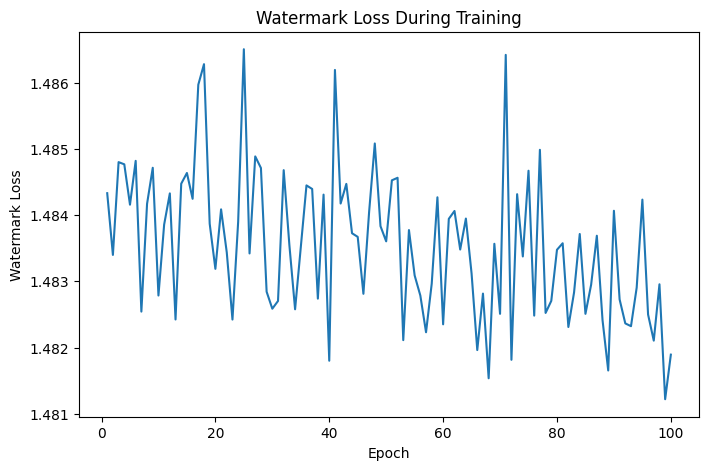

In [14]:
wm_loss = metrics["epoch_losses_wm"]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(wm_loss) + 1), wm_loss)

plt.xlabel("Epoch")
plt.ylabel("Watermark Loss")
plt.title("Watermark Loss During Training")

plt.show()

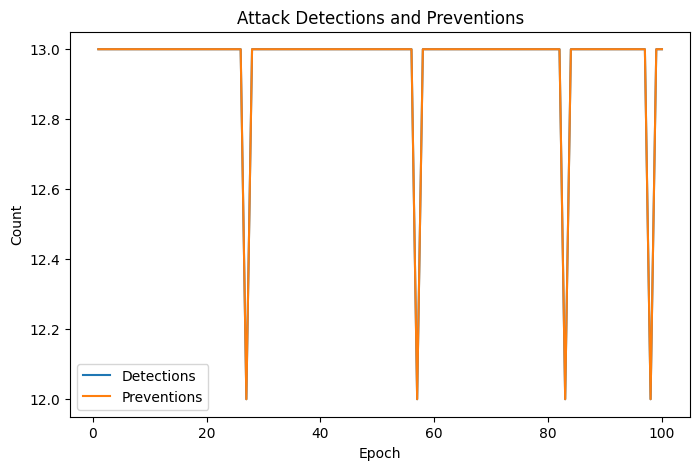

In [15]:
detections = metrics["detections_per_epoch"]
preventions = metrics["preventions_per_epoch"]

epochs = range(1, len(detections) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, detections, label="Detections")
plt.plot(epochs, preventions, label="Preventions")

plt.xlabel("Epoch")
plt.ylabel("Count")
plt.title("Attack Detections and Preventions")
plt.legend()

plt.show()

In [16]:
dist = metrics["attack_distribution_per_epoch"]

print("Number of epochs:", len(dist))
print("\nFirst 3 entries:")
print(dist[:3])

Number of epochs: 100

First 3 entries:
[{'noise': 3, 'sign_flip': 2, 'quant': 5, 'pruning': 3}, {'quant': 7, 'sign_flip': 4, 'noise': 1, 'pruning': 1}, {'sign_flip': 4, 'noise': 2, 'pruning': 4, 'quant': 3}]


In [17]:
latency = stats["avg_detection_time_ms"]

print(f"Average attack detection latency: {latency:.2f} ms")

Average attack detection latency: 12.96 ms


In [18]:
final_bit_acc = metrics["bit_accuracies"][-1] * 100

print(f"Final watermark bit accuracy: {final_bit_acc:.2f}%")

Final watermark bit accuracy: 54.69%


In [19]:
best_bit_acc = max(metrics["bit_accuracies"]) * 100
best_epoch = np.argmax(metrics["bit_accuracies"]) + 1

print(f"Best watermark bit accuracy: {best_bit_acc:.2f}%")
print(f"Best epoch: {best_epoch}")

Best watermark bit accuracy: 54.69%
Best epoch: 57


## Preliminary Findings

The current experiment evaluates four model-level perturbations:
pruning, Gaussian noise injection, quantization, and sign flipping.

The IDS currently shows substantial confusion between attack types,
particularly for pruning, quantization, and sign-flip attacks.

The language-model loss decreases substantially during training,
indicating that the language-model objective is being optimized.

However, the watermark bit accuracy remains close to chance level
in the current experiment, indicating that the watermark objective
requires further investigation.

The prototype attack detector achieves different classification
accuracies across attack types, with stronger performance on
quantization than on sign-flip and noise attacks.

The current experiment reports an average attack detection latency
of approximately 12.96 ms.

These results are considered preliminary and are used to identify
limitations in the current watermark training and attack detection
pipeline. Further experiments will be performed after improving
the training procedure.

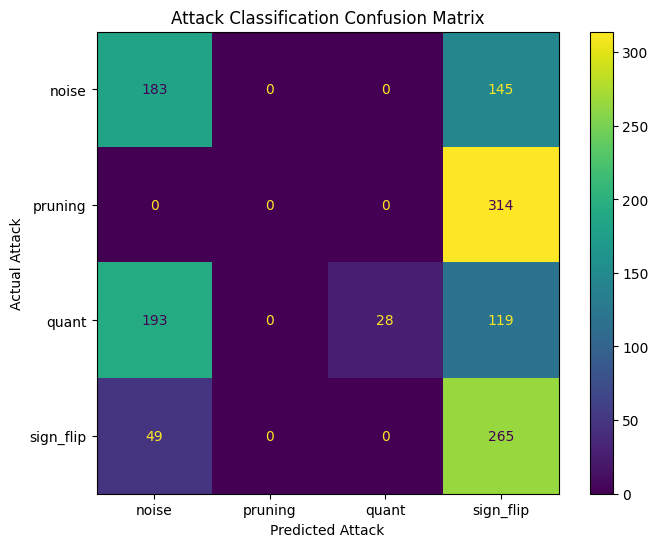

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

events = stats["attack_events"]

actual = [x["actual_type"] for x in events]
pred = [x["detected_type"] for x in events]

labels = sorted(set(actual + pred))

cm = confusion_matrix(actual, pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, values_format="d")

plt.title("Attack Classification Confusion Matrix")
plt.xlabel("Predicted Attack")
plt.ylabel("Actual Attack")

plt.show()

In [21]:
from sklearn.metrics import classification_report

print(classification_report(
    actual,
    pred,
    labels=labels,
    zero_division=0
))

              precision    recall  f1-score   support

       noise       0.43      0.56      0.49       328
     pruning       0.00      0.00      0.00       314
       quant       1.00      0.08      0.15       340
   sign_flip       0.31      0.84      0.46       314

    accuracy                           0.37      1296
   macro avg       0.44      0.37      0.27      1296
weighted avg       0.45      0.37      0.27      1296

